In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print("Found GPU")
else:
    torch.device("cpu")
    
print("Pytorch version:", torch.__version__)

Found GPU
Pytorch version: 2.4.1+cu121


## Login to Wandb to log experiment

In [3]:
os.environ['WANDB_NOTEBOOK_NAME'] = 'EuroSat_MobileNet_Classifier.ipynb'



In [4]:
# NEW (your local Windows path)
data_path = r"C:\Users\Ekagr\Desktop\eurosat_classification\train_eval_code\dataset_rgb\\"


In [5]:
# Load the labels 
f = open(f"{data_path}label_map.json", "r")
label_to_index = json.load(f)

In [6]:
index_to_label = {label_to_index[k]:k for k in label_to_index}
print(index_to_label)

{0: 'AnnualCrop', 1: 'Forest', 2: 'HerbaceousVegetation', 3: 'Highway', 4: 'Industrial', 5: 'Pasture', 6: 'PermanentCrop', 7: 'Residential', 8: 'River', 9: 'SeaLake'}


## Data Transformations

In [7]:
# Define a sequence of transformations to be applied to images
transformToTensor = transforms.Compose([
    # Resize the image to have a minimum size of 64 pixels along the shortest dimension,
    # preserving the aspect ratio of the original image.
    transforms.Resize((64,)),

    # Crop the image at the center to get a 64x64 square.
    transforms.CenterCrop((64, 64)),

    # Convert the image to a PyTorch tensor.
    transforms.ToTensor(),

    # Normalize the tensor image with mean and standard deviation for each color channel.
    # These specific values are generally used for pre-trained models.
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Create dataset instances
# Instantiate the EurosatDataset class for training data.
train_dataset = EurosatDataset(_type='train', transform=transformToTensor,
                               data_path=data_path)

# Instantiate the EurosatDataset class for validation data.
valid_dataset = EurosatDataset(_type="valid", transform=transformToTensor,
                               data_path=data_path)

# Instantiate the EurosatDataset class for testing data.
test_dataset = EurosatDataset(_type="test", transform=transformToTensor,
                              data_path=data_path)

# Define batch sizes for training and validation data.
train_batch = 64  # The batch size for training data.
val_batch = 16     # The batch size for validation data.


train_loader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True)


valid_loader = DataLoader(valid_dataset, batch_size=val_batch, shuffle=False)


test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

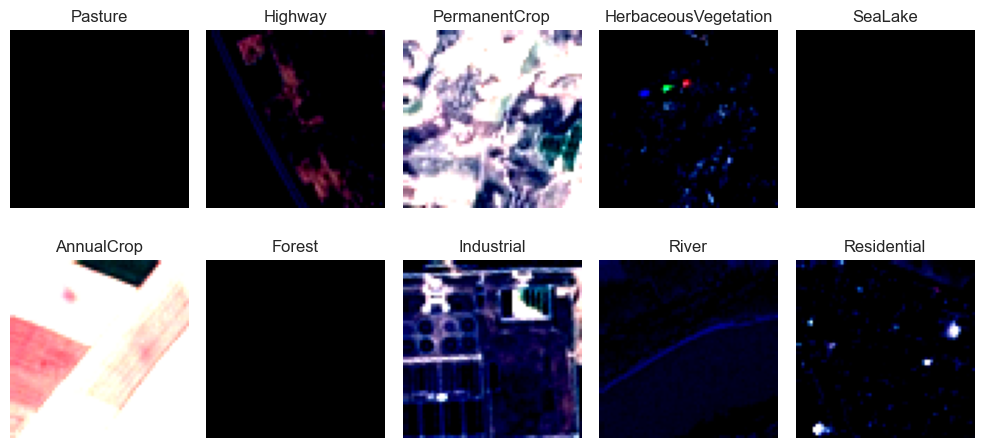

In [9]:
visualize_classes(train_loader, index_to_label)

In [10]:
dataset_managers = {
    'valid': valid_loader,
    'train': train_loader,
    'test': test_loader
}

print(f"Train set batches: {len(train_loader)}")
print(f"Validation set batches: {len(valid_loader)}")
print(f"Test set examples: {len(test_loader)}")

Train set batches: 296
Validation set batches: 338
Test set examples: 2700


## Labels distribution

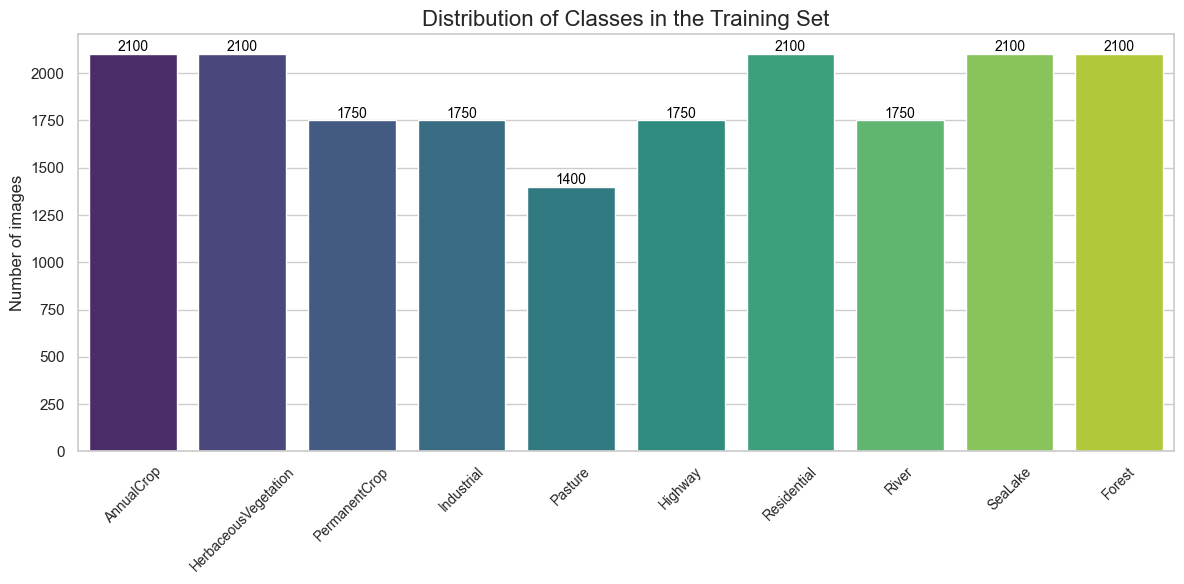

In [11]:
labels = train_dataset.data['Label'].values  # Assuming 'Label' is the column with labels

# Convert numerical labels to string names if necessary
label_names = [index_to_label[label] for label in labels]

sns.set(style="whitegrid")  # Set style
plt.figure(figsize=(12, 6))

# Adjusted according to the new API
ax = sns.countplot(x=label_names, hue=label_names, palette="viridis", legend=False)

#plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.title('Distribution of Classes in the Training Set', fontsize=16)
plt.xticks(rotation=45, fontsize=10)

# Add the count above the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()



# Model

In [12]:
# Use un-pretrained model
model = mobilenet_v3_small()

# Replace the model head with the number of classes
num_classes = 10
model.classifier[3] = nn.Linear(1024, num_classes) 
model.to(DEVICE)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

# Training model from Scratch

In [16]:
project_name = "EuroSAT"
model_name = "MobileNetV3"
models_path = "/datasets2/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models"

In [17]:
epochs = 200
lr = 0.0001
patience = 10

print("Training started...")

loss_i, loss_val_i = train_model(model=model, epochs=epochs, 
                                 train_loader=train_loader,
                                 valid_loader=valid_loader,
                                 model_name='MobileNet',   # ← add this
                                 lr=lr, patience=patience, device=DEVICE)


Training started...
Starting training with early stopping patience of 10
Each epoch has 296 steps.

Epoch: 1...
Step: 21/296 | Train Loss: 2.3378
Step: 41/296 | Train Loss: 2.1577
Step: 61/296 | Train Loss: 2.0336
Step: 81/296 | Train Loss: 1.7935
Step: 101/296 | Train Loss: 1.6519
Step: 121/296 | Train Loss: 1.5056
Step: 141/296 | Train Loss: 1.5018
Step: 161/296 | Train Loss: 1.4284
Step: 181/296 | Train Loss: 1.3541
Step: 201/296 | Train Loss: 1.2845
Step: 221/296 | Train Loss: 1.3156
Step: 241/296 | Train Loss: 1.2380
Step: 261/296 | Train Loss: 1.1920
Step: 281/296 | Train Loss: 1.2002
Val Loss: 2.3495 | Val Accuracy: 0.0741 (7.41%)
Best model saved.
Epoch duration: 34.16s

Epoch: 2...
Step: 21/296 | Train Loss: 2.4539
Step: 41/296 | Train Loss: 2.3127
Step: 61/296 | Train Loss: 2.3001
Step: 81/296 | Train Loss: 2.2937
Step: 101/296 | Train Loss: 2.2968
Step: 121/296 | Train Loss: 2.3001
Step: 141/296 | Train Loss: 2.2948
Step: 161/296 | Train Loss: 2.2944
Step: 181/296 | Train Lo

## Save model

In [18]:
# Create models directory
os.makedirs(models_path, exist_ok=True)

# 2. Create model save path
model_save_path = os.path.join(models_path, model_name + ".pth")

# 3. Save the model state dict
print(f"Saving model to: {model_save_path}")
torch.save(obj=model.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=model_save_path)

Saving model to: /datasets2/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models\MobileNetV3.pth


In [19]:
# Save the loss data in a file
with open(f"{models_path}/loss_{model_name}.txt", "w") as file:
    file.write(f"loss_i: {loss_i}\n")
    file.write(f"loss_val_i: {loss_val_i}\n")

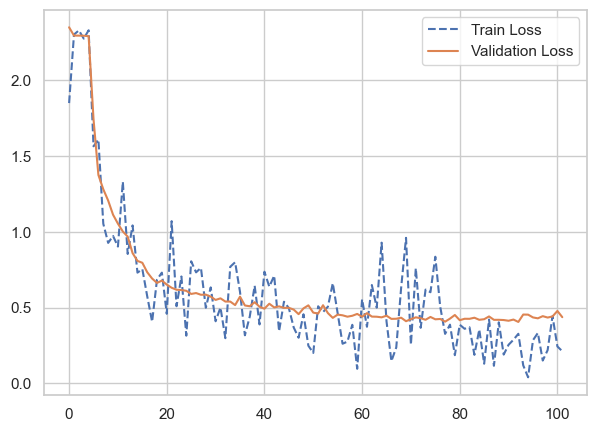

In [20]:
plt.figure(figsize=(7,5))
# Use a dashed line for the training loss, and add markers
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)

# Use a solid line for the validation loss
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()

# Evaluate model

## Load trained model

In [23]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
model_save_path = models_path + "/" + model_name + ".pth"
print(f"Loading {model_save_path}")
model.load_state_dict(torch.load(f = model_save_path))

Loading /datasets2/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models/MobileNetV3.pth


C:\Users\Ekagr\AppData\Local\Temp\ipykernel_43772\397842506.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f = model_save_path))


<All keys matched successfully>

In [24]:
evaluate_test_set(model, test_loader, DEVICE, index_to_label=index_to_label)

                      precision    recall  f1-score   support

          AnnualCrop      0.887     0.887     0.887       300
              Forest      0.977     0.973     0.975       300
HerbaceousVegetation      0.842     0.817     0.829       300
             Highway      0.800     0.656     0.721       250
          Industrial      0.919     0.948     0.933       250
             Pasture      0.814     0.855     0.834       200
       PermanentCrop      0.776     0.816     0.795       250
         Residential      0.927     0.967     0.946       300
               River      0.824     0.840     0.832       250
             SeaLake      0.964     0.983     0.974       300

            accuracy                          0.879      2700
           macro avg      0.873     0.874     0.873      2700
        weighted avg      0.878     0.879     0.878      2700



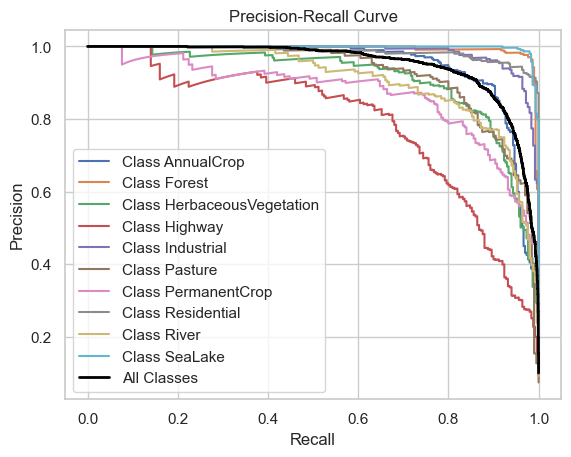

In [25]:
precision_recall_analysis(model, test_loader, DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

## Load the precision/recall curve and plot it

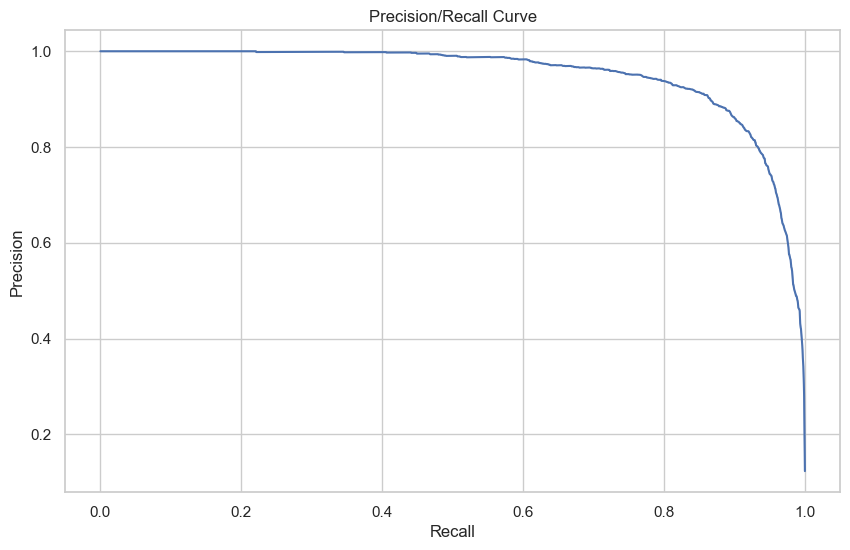

In [26]:
filename = f"{model_name}_precision_recall_values.json"
file_path = os.path.join(models_path, filename)

with open(file_path, 'r') as file:
    precision_recall_data = json.load(file)
    
all_classes_data = precision_recall_data['All Classes']

# Extract precision and recall values
precisions = all_classes_data.get('precision', [])
recalls = all_classes_data.get('recall', [])

# Create a DataFrame for plotting
df = pd.DataFrame({
    'Precision': precisions,
    'Recall': recalls
})

# Plotting the precision/recall curve
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Recall', y='Precision')
plt.title('Precision/Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

## Clean-up

In [27]:
import gc

del model
torch.cuda.empty_cache()
gc.collect()


9992

# Now train the model with pre-trained weights

In [12]:
# Use pretrained model
model2=mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# Replace the model head with the number of classes
num_classes = 10
model2.classifier[3] = nn.Linear(1024, num_classes) 
model2.to(DEVICE)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

## Train

In [13]:
model_name = "MobileNetV3-Pretrained"

In [14]:
epochs = 200
lr = 0.0001
patience = 10

print("Training started...")

loss_i, loss_val_i = train_model(model=model2, epochs=epochs, 
                                 train_loader=train_loader,
                                 valid_loader=valid_loader,
                                 lr=lr, patience=patience, device=DEVICE)

Training started...
Starting training with early stopping patience of 10
Each epoch has 296 steps.

Epoch: 1...
Step: 21/296 | Train Loss: 2.4622
Step: 41/296 | Train Loss: 1.8944
Step: 61/296 | Train Loss: 1.5448
Step: 81/296 | Train Loss: 1.3137
Step: 101/296 | Train Loss: 1.1040
Step: 121/296 | Train Loss: 0.9380
Step: 141/296 | Train Loss: 0.8599
Step: 161/296 | Train Loss: 0.8033
Step: 181/296 | Train Loss: 0.7422
Step: 201/296 | Train Loss: 0.6876
Step: 221/296 | Train Loss: 0.6495
Step: 241/296 | Train Loss: 0.5547
Step: 261/296 | Train Loss: 0.5376
Step: 281/296 | Train Loss: 0.5366
Val Loss: 0.4336 | Val Accuracy: 0.8519 (85.19%)
Best model saved.
Epoch duration: 110.57s

Epoch: 2...
Step: 21/296 | Train Loss: 0.4327
Step: 41/296 | Train Loss: 0.3835
Step: 61/296 | Train Loss: 0.3157
Step: 81/296 | Train Loss: 0.2951
Step: 101/296 | Train Loss: 0.3313
Step: 121/296 | Train Loss: 0.2744
Step: 141/296 | Train Loss: 0.2229
Step: 161/296 | Train Loss: 0.2686
Step: 181/296 | Train 

## Save model

In [17]:
# Create models directory
os.makedirs(models_path, exist_ok=True)

# 2. Create model save path
model_save_path = os.path.join(models_path, model_name + ".pth")

# 3. Save the model state dict
print(f"Saving model to: {model_save_path}")
torch.save(obj=model2.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=model_save_path)

Saving model to: /datasets2/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models\MobileNetV3.pth


In [18]:
# Save the loss data in a file
with open(f"{models_path}/loss_{model_name}.txt", "w") as archivo:
    archivo.write(f"loss_i: {loss_i}\n")
    archivo.write(f"loss_val_i: {loss_val_i}\n")

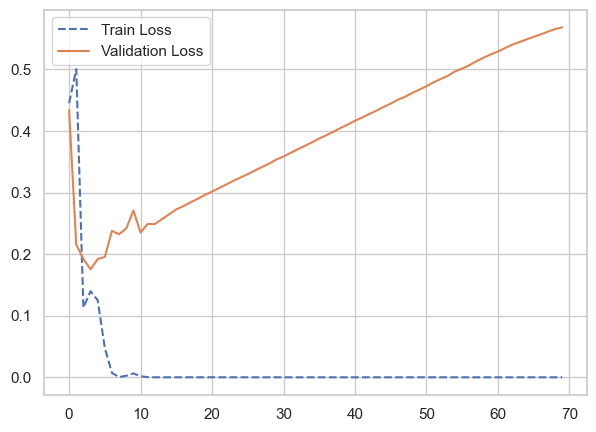

In [19]:
plt.figure(figsize=(7,5))
# Use a dashed line for the training loss, and add markers
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)

# Use a solid line for the validation loss
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()

# Evaluate model

## Load trained model

In [22]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
model_save_path = models_path + "/" + model_name + ".pth"
print(f"Loading {model_save_path}")
model2.load_state_dict(torch.load(f = model_save_path))

Loading /datasets2/Dropbox/Projects/remote_sensing/LC_classification_pytorch/models/MobileNetV3.pth


C:\Users\Ekagr\AppData\Local\Temp\ipykernel_62248\3005568182.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model2.load_state_dict(torch.load(f = model_save_path))


<All keys matched successfully>

In [23]:
evaluate_test_set(model2, test_loader, DEVICE, index_to_label=index_to_label)

                      precision    recall  f1-score   support

          AnnualCrop      0.980     0.960     0.970       300
              Forest      0.980     0.993     0.987       300
HerbaceousVegetation      0.920     0.963     0.941       300
             Highway      0.904     0.940     0.922       250
          Industrial      0.964     0.956     0.960       250
             Pasture      0.945     0.950     0.948       200
       PermanentCrop      0.935     0.864     0.898       250
         Residential      0.977     0.993     0.985       300
               River      0.951     0.928     0.939       250
             SeaLake      1.000     0.997     0.998       300

            accuracy                          0.957      2700
           macro avg      0.956     0.954     0.955      2700
        weighted avg      0.957     0.957     0.957      2700



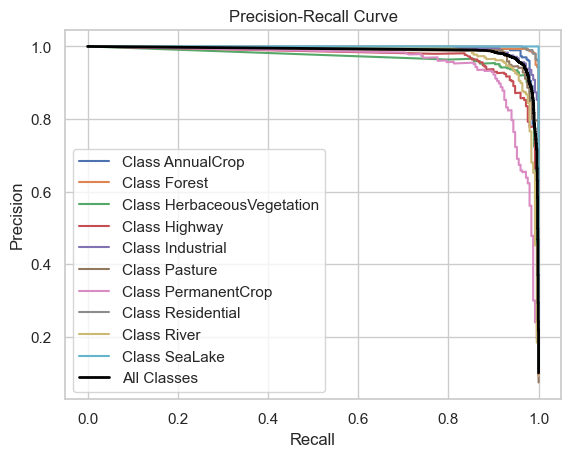

In [24]:
precision_recall_analysis(model2, test_loader, DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

In [25]:
del model2
torch.cuda.empty_cache()
gc.collect()

NameError: name 'gc' is not defined